In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set style for plots
sns.set_style('whitegrid')

In [ ]:
!uv pip install nbformat>=4.2.0

In [3]:
# Load the dataset
df = pd.read_csv('../data/diamonds.csv')
print('Dataset shape:', df.shape)
print('Columns:', list(df.columns))
df.head()

Dataset shape: (53940, 10)
Columns: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'price']


,carat,cut,color,clarity,depth,table,x,y,z,price
0,0.23,Ideal,E,SI2,61.5,55.0,3.95,3.98,2.43,326
1,0.21,Premium,E,SI1,59.8,61.0,3.89,3.84,2.31,326
2,0.23,Good,E,VS1,56.9,65.0,4.05,4.07,2.31,327
3,0.29,Premium,I,VS2,62.4,58.0,4.20,4.23,2.63,334
4,0.31,Good,J,SI2,63.3,58.0,4.34,4.35,2.75,335


In [4]:
# Basic statistics
df.describe()

,carat,depth,table,x,y,z,price
count,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000,53940.000000
mean,0.797940,61.749405,57.457184,5.731157,5.734526,3.538734,3932.799722
std,0.474011,1.432621,2.234491,1.121761,1.142135,0.705699,3989.439738
min,0.200000,43.000000,43.000000,0.000000,0.000000,0.000000,326.000000
25%,0.400000,61.000000,56.000000,4.710000,4.720000,2.910000,950.000000
50%,0.700000,61.800000,57.000000,5.700000,5.710000,3.530000,2401.000000
75%,1.040000,62.500000,59.000000,6.540000,6.540000,4.040000,5324.250000
max,5.010000,79.000000,95.000000,10.740000,58.900000,31.800000,18823.000000


In [5]:
# Check for missing values
df.isnull().sum()

carat      0
cut        0
color      0
clarity    0
depth      0
table      0
x          0
y          0
z          0
price      0
dtype: int64

In [6]:
# Data types
df.dtypes

carat      float64
cut         object
color       object
clarity     object
depth      float64
table      float64
x          float64
y          float64
z          float64
price        int64
dtype: object

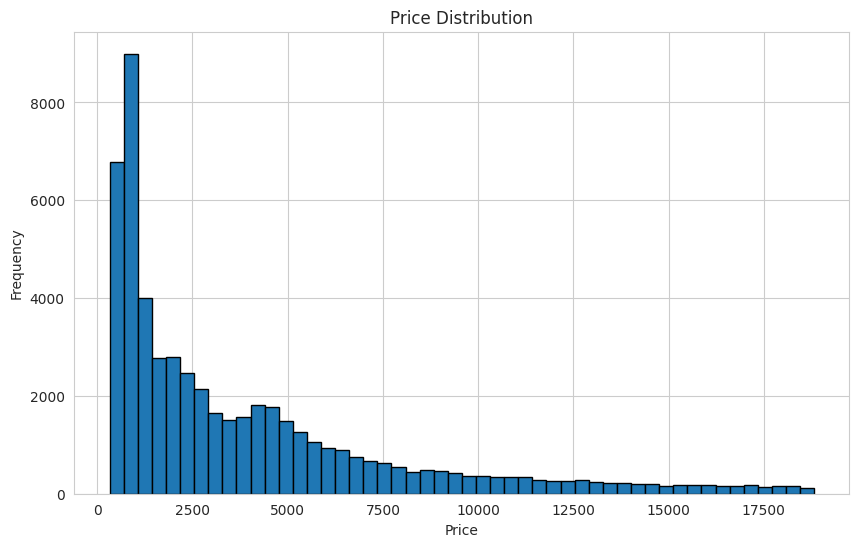

In [20]:
# EDA: Distribution of price
plt.figure(figsize=(10,6))
plt.hist(df['price'], bins=50, edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.savefig('../viz/price_distribution.png')
plt.show()

In [ ]:
# EDA: Carat vs Price
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='carat', y='price', hue='cut')
plt.title('Carat vs Price by Cut')
plt.savefig('../viz/carat_price_scatter.png')
plt.show()

In [9]:
# EDA: Correlation heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(12,8))
sns.heatmap(df[numeric_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.savefig('../viz/correlation_heatmap.png')
plt.show()

In [ ]:
# EDA: Cut distribution
plt.figure(figsize=(8,6))
df['cut'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Cut Distribution')
plt.ylabel('')
plt.savefig('../viz/cut_distribution.png')
plt.show()

In [ ]:
# EDA: Color vs Price
plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='color', y='price')
plt.title('Price by Color')
plt.savefig('../viz/color_price_box.png')
plt.show()

In [ ]:
# EDA: Clarity vs Price
plt.figure(figsize=(10,6))
sns.violinplot(data=df, x='clarity', y='price')
plt.title('Price Distribution by Clarity')
plt.savefig('../viz/clarity_price_violin.png')
plt.show()

In [21]:
# Preprocessing for ML
# Encode categorical variables
le_cut = LabelEncoder()
df['cut_encoded'] = le_cut.fit_transform(df['cut'])

le_color = LabelEncoder()
df['color_encoded'] = le_color.fit_transform(df['color'])

le_clarity = LabelEncoder()
df['clarity_encoded'] = le_clarity.fit_transform(df['clarity'])

# Select features
features = ['carat', 'depth', 'table', 'x', 'y', 'z', 'cut_encoded', 'color_encoded', 'clarity_encoded']
X = df[features]
y = df['price']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

MAE: 267.72
RMSE: 542.20
R²: 0.9815


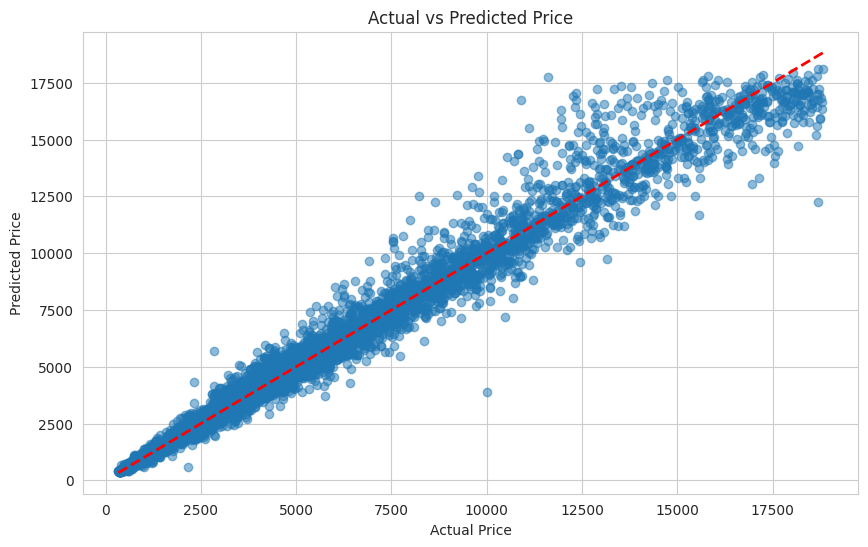

In [22]:
# Train Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train_scaled, y_train)

# Predictions
y_pred = rf_model.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f'MAE: {mae:.2f}')
print(f'RMSE: {rmse:.2f}')
print(f'R²: {r2:.4f}')

# Actual vs Predicted plot
plt.figure(figsize=(10,6))
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Price')
plt.savefig('../viz/actual_vs_predicted.png')
plt.show()

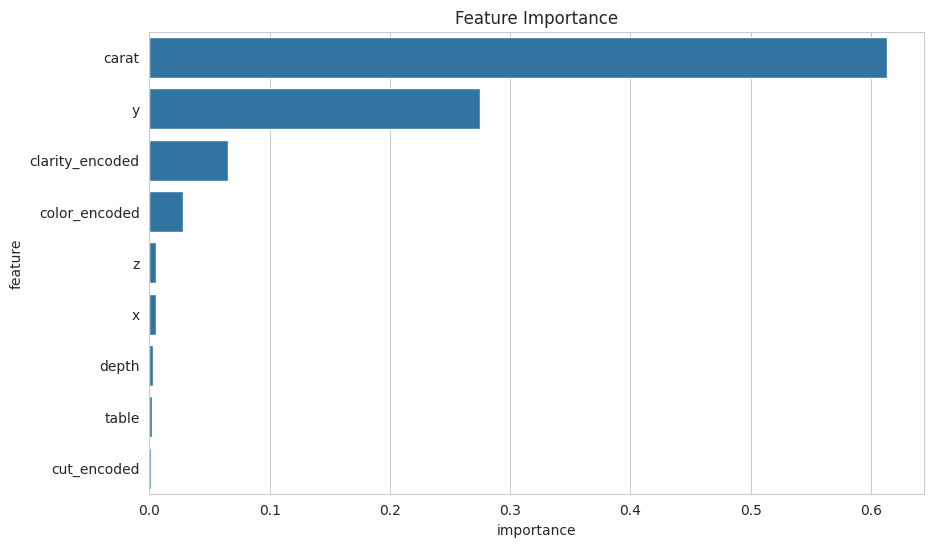

In [23]:
# Feature importance
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=feature_importance, x='importance', y='feature')
plt.title('Feature Importance')
plt.savefig('../viz/feature_importance.png')
plt.show()

In [24]:
# Create a pipeline for the model
from sklearn.pipeline import Pipeline

# Define the pipeline
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])

# Fit the pipeline
pipeline.fit(X_train, y_train)

# Example prediction
sample_diamond = pd.DataFrame({
    'carat': [1.0],
    'depth': [62.0],
    'table': [55.0],
    'x': [6.5],
    'y': [6.5],
    'z': [4.0],
    'cut_encoded': [le_cut.transform(['Ideal'])[0]],
    'color_encoded': [le_color.transform(['D'])[0]],
    'clarity_encoded': [le_clarity.transform(['VS1'])[0]]
})

# Make prediction
prediction = pipeline.predict(sample_diamond)

print('Sample Diamond Prediction:')
print(f'Predicted Price: ${prediction[0]:.2f}')

Sample Diamond Prediction:
Predicted Price: $8720.40
